# 07 - Positive Control

Measures whether the detection chain finds plumes that are **known to be present**.

Everything before this notebook is uncalibrated. Notebooks 03-06 produce REJECT
verdicts, and those may well be correct - but a method that rejects everything is
indistinguishable from a broken one until it has accepted something real.

### Control scene

`20241004_081921_28_4001` - Iraq, Energy & Mining collection, 2024-10-04.
Selected because Planet's own `ql_ch4_json` reports plumes **inside this frame**,
which is the ground truth the Casa Grande audit in notebook 06 showed to be
decisive.

### Ground-truth sources, in order of trust

1. **`ql_ch4_json`** (Planet, per-frame). Frame-specific by construction - no
   ambiguity about whether a detection belongs to this acquisition.
2. **Carbon Mapper catalog** (cross-check). Queried by bbox, then **filtered to
   the scene date**. Notebook 06 found 67 plumes in the Casa Grande footprint
   spanning 2025-2026 at a permanent release testbed; an unfiltered bbox query
   returns every plume ever cataloged at that location. At producing
   infrastructure, the same wellhead leaks repeatedly, so unfiltered results look
   plausible and are wrong.

### What this notebook measures

- What scene percentile do known plumes reach under the column-wise filter?
- Does the validation chain ACCEPT pixels at known plume locations?
- What threshold captures known plumes, and what false-positive rate comes with it?

Thresholds are fitted on a subset of plumes and evaluated on held-out plumes.
Tuning and evaluating on the same data would be circular.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone
from matplotlib.path import Path as MplPath

import pystac
from tanager_diagnostics import (
    load_scene, swir_matrix, hitran_ch4_k,
    matched_filter_columnwise, score_at_coords,
    background_stats, build_target, matched_filter,
    brightness_matched_ratio, hitran_shape_test,
    ValidationResult, _verdict,
    BAND_LO, BAND_HI,
)

SCENE_ID   = "20241004_081921_28_4001"
SCENE_PATH = f"../data/raw/{SCENE_ID}_basic_radiance.h5"
ITEM_URL   = ("https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/"
              f"{SCENE_ID}/{SCENE_ID}.json")

FIGDIR = Path("../outputs/figures"); FIGDIR.mkdir(parents=True, exist_ok=True)
CACHE  = Path("../data/processed");  CACHE.mkdir(parents=True, exist_ok=True)
RAW    = Path("../data/raw");        RAW.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260731)   # fixed seed: splits are reproducible
print("ready")

ready


## 1. Fetch the scene

In [3]:
item = pystac.Item.from_file(ITEM_URL)

print("location :", item.properties.get("location_description"))
print("datetime :", item.datetime)
print("notes    :", item.properties.get("notes"))
print("gsd      :", item.properties.get("gsd"), "m")
print("off-nadir:", item.properties.get("view:off_nadir"), "deg")
print("haze     :", item.properties.get("light_haze_percent"), "%")
print("bbox     :", [round(v, 5) for v in item.bbox])
print("plume ids:", item.properties.get("plume_provider_ids"))

location : As-Sa'duni, Khasham Subdistrict, Deir ez-Zor District, Deir ez-Zor Governorate, Syria
datetime : 2024-10-04 08:19:21.283920+00:00
notes    : Plumes E and F represent the combined plume formed by merging sources that share a single emission rate.
gsd      : 39.12 m
off-nadir: 2.8 deg
haze     : 0 %
bbox     : [40.19932, 35.15176, 40.51317, 35.43528]
plume ids: ['tan20241004t081910c00s4001-A', 'tan20241004t081910c00s4001-B', 'tan20241004t081910c00s4001-C', 'tan20241004t081910c00s4001-D', 'tan20241004t081910c00s4001-E', 'tan20241004t081910c00s4001-F', 'tan20241004t081910c00s4001-G', 'tan20241004t081910c00s4001-H', 'tan20241004t081910c00s4001-I', 'tan20241004t081910c00s4001-J']


In [4]:
if not Path(SCENE_PATH).exists():
    href = item.assets["basic_radiance_hdf5"].href
    print("downloading...")
    r = requests.get(href, stream=True, timeout=120); r.raise_for_status()
    with open(SCENE_PATH, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)

size_mb = Path(SCENE_PATH).stat().st_size / 1e6
print(f"{size_mb:.0f} MB")
assert size_mb > 100, "Truncated download - delete the file and retry"

609 MB


## 2. Ground truth from `ql_ch4_json`

Frame-specific: whatever this contains belongs to this acquisition. Geometry may
be Points or Polygons depending on the product, so both are handled - polygons
give a plume *extent*, which is more useful than a centroid.

In [5]:
ql = item.assets.get("ql_ch4_json")
assert ql is not None, "No ql_ch4_json asset - pick a different control scene"

r = requests.get(ql.href, timeout=60); r.raise_for_status()
fc = r.json()
feats = fc.get("features", [])
print(f"features in frame: {len(feats)}")

if not feats:
    raise RuntimeError(
        "Empty FeatureCollection - this frame has no Planet-detected plume. "
        "Choose another scene; see notebook 06 for why this check matters."
    )

print("\nfirst feature properties:")
for k, v in (feats[0].get("properties") or {}).items():
    print(f"  {k}: {v}")
print("\ngeometry type:", feats[0]["geometry"]["type"])

features in frame: 12

first feature properties:
  datetime: 2024-10-04T08:19:10+00:00
  emission: 446.01844972298466
  emission_uncertainty: 85.77085922991202
  fetch: 810.0
  ime: 40.899050295352936
  plume_id: 20241004_081910_00_4001_strip_A
  plume_provider: carbon_mapper
  plume_provider_id: tan20241004t081910c00s4001-A
  plume_provider_version: version:v3;processing_software:cmpro=3.39.1
  plume_quality: good
  wind_direction_avg: 293.0
  wind_direction_std: 2.4497696466142798
  wind_source: ecmwf_ifs
  wind_speed_avg: 2.4537037037037037
  wind_speed_std: 0.4196395997638762

geometry type: Point


In [6]:
def feature_centroid(geom):
    """Centroid as (lon, lat) for Point / Polygon / MultiPolygon."""
    t, c = geom["type"], geom["coordinates"]
    if t == "Point":
        return float(c[0]), float(c[1])
    if t == "Polygon":
        ring = np.asarray(c[0], dtype=float)
    elif t == "MultiPolygon":
        ring = np.vstack([np.asarray(p[0], dtype=float) for p in c])
    else:
        raise ValueError(f"unhandled geometry: {t}")
    return float(ring[:, 0].mean()), float(ring[:, 1].mean())


truth = []
for i, f in enumerate(feats):
    lon_c, lat_c = feature_centroid(f["geometry"])
    props = f.get("properties") or {}
    truth.append({
        "label": props.get("plume_id") or props.get("id") or f"planet-{i:02d}",
        "lat": lat_c, "lon": lon_c,
        "geometry": f["geometry"],
        "emission": props.get("emission") or props.get("emission_auto"),
    })

truth_df = pd.DataFrame([{k: v for k, v in t.items() if k != "geometry"}
                         for t in truth])
print(f"{len(truth)} ground-truth plumes in frame\n")
print(truth_df.to_string(index=False))

12 ground-truth plumes in frame

                          label       lat       lon    emission
20241004_081910_00_4001_strip_A 35.367187 40.415651  446.018450
20241004_081910_00_4001_strip_B 35.352636 40.374429  947.060049
20241004_081910_00_4001_strip_C 35.349658 40.368053  173.829073
20241004_081910_00_4001_strip_D 35.352183 40.337647 3188.932691
20241004_081910_00_4001_strip_E 35.347257 40.281942 1150.274082
20241004_081910_00_4001_strip_F 35.346581 40.279839 1151.947043
20241004_081910_00_4001_strip_G 35.343874 40.260482  594.918561
20241004_081910_00_4001_strip_H 35.315477 40.416479 1231.059431
20241004_081910_00_4001_strip_I 35.306957 40.444042 1373.727440
20241004_081910_00_4001_strip_J 35.296975 40.435288  977.164188
20241004_081910_00_4001_strip_K 35.298833 40.425273  366.006702
20241004_081910_00_4001_strip_L 35.383658 40.315729  149.551857


## 3. Carbon Mapper cross-check - with a date filter

The `plume_names` parameter is silently ignored by this endpoint, so query by
bbox. Then **filter to the scene date**. Without that filter this returns every
plume ever cataloged in the footprint, which at producing infrastructure means
repeat leaks at the same coordinates across years.

In [7]:
W, S, E, N = item.bbox
PAD = 0.02
scene_date = item.datetime.astimezone(timezone.utc).date()

resp = requests.get(
    "https://api.carbonmapper.org/api/v1/catalog/plumes/annotated",
    params=[("bbox", W - PAD), ("bbox", S - PAD),
            ("bbox", E + PAD), ("bbox", N + PAD),
            ("limit", 500), ("offset", 0)],
    timeout=60,
)
resp.raise_for_status()
cm_all = resp.json().get("items", [])
print(f"{len(cm_all)} plume(s) in footprint across ALL dates")


def plume_date(p):
    """Scene date for a catalog entry; falls back to parsing the plume id."""
    for key in ("scene_timestamp", "datetime", "observed_at"):
        v = p.get(key)
        if v:
            try:
                return datetime.fromisoformat(str(v).replace("Z", "+00:00")).date()
            except ValueError:
                pass
    pid = str(p.get("plume_id", ""))
    for i in range(len(pid) - 7):
        chunk = pid[i:i+8]
        if chunk.isdigit():
            try:
                return datetime.strptime(chunk, "%Y%m%d").date()
            except ValueError:
                continue
    return None


cm_same_day = [p for p in cm_all if plume_date(p) == scene_date]
cm_ch4 = [p for p in cm_same_day if str(p.get("gas", "")).upper() == "CH4"]

print(f"  -> {len(cm_same_day)} on the scene date ({scene_date})")
print(f"  -> {len(cm_ch4)} of those are CH4\n")

for p in cm_ch4:
    lon_p, lat_p = p["geometry_json"]["coordinates"]
    print(f"  {p.get('plume_id')}  {lat_p:.5f}, {lon_p:.5f}  "
          f"{p.get('emission_auto')} kg/hr")

if len(cm_all) > len(cm_same_day):
    print(f"\nNOTE: {len(cm_all) - len(cm_same_day)} plume(s) at these coordinates "
          "are from other dates. An unfiltered query would have used them as "
          "ground truth for this scene.")

53 plume(s) in footprint across ALL dates
  -> 14 on the scene date (2024-10-04)
  -> 14 of those are CH4

  tan20241004t081910c00s4001-A  35.36719, 40.41565  446.01844972298466 kg/hr
  tan20241004t081910c00s4001-B  35.35264, 40.37443  947.0600485404332 kg/hr
  tan20241004t081910c00s4001-C  35.34966, 40.36805  173.82907339820156 kg/hr
  tan20241004t081910c00s4001-D  35.35218, 40.33765  3188.9326914034637 kg/hr
  tan20241004t081910c00s4001-E  35.34726, 40.28194  None kg/hr
  tan20241004t081910c00s4001-F  35.34658, 40.27984  1151.9470433845663 kg/hr
  tan20241004t081910c00s4001-G  35.34387, 40.26048  594.9185606056735 kg/hr
  tan20241004t081910c00s4001-H  35.31548, 40.41648  1231.0594314999053 kg/hr
  tan20241004t081910c00s4001-I  35.30696, 40.44404  1373.7274397004792 kg/hr
  tan20241004t081910c00s4001-J  35.29698, 40.43529  977.1641884909735 kg/hr
  tan20241004t081910c00s4001-K  35.29883, 40.42527  366.0067021581862 kg/hr
  tan20241004t081910c00s4001-L  35.38366, 40.31573  149.55185692

## 4. Column-wise matched filter

In [8]:
rad, wl, lat, lon = load_scene(SCENE_PATH)
X, wl_swir, valid, shape = swir_matrix(rad, wl)

k = hitran_ch4_k(wl_swir)
assert k is not None, "hapi unavailable - pip install hitran-api"
print(f"SWIR bands {len(wl_swir)} | HITRAN peak {wl_swir[np.argmax(k)]:.1f} nm")

MF_PATH = CACHE / f"mf_columnwise_{SCENE_ID}.npy"
if MF_PATH.exists():
    mf = np.load(MF_PATH)
    print(f"loaded cache: {MF_PATH}")
else:
    mf, _, info = matched_filter_columnwise(rad, wl, k, progress=True)
    np.save(MF_PATH, mf)
    print(f"cached: {MF_PATH}")
    print(f"shrinkage {info['shrinkage_min']:.3f}-{info['shrinkage_max']:.3f} "
          f"(mean {info['shrinkage_mean']:.3f}) | skipped {info['columns_skipped']}")

print(f"shape {mf.shape} | valid {np.isfinite(mf).sum():,}")

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [10]:
import requests, os
from pathlib import Path

p = Path(SCENE_PATH)
if p.exists():
    p.unlink()

href = item.assets["basic_radiance_hdf5"].href
r = requests.get(href, stream=True, timeout=300)
r.raise_for_status()

expected = int(r.headers.get("Content-Length", 0))
print(f"expected: {expected/1e6:.0f} MB")

with open(p, "wb") as f:
    for chunk in r.iter_content(1 << 20):
        f.write(chunk)

got = p.stat().st_size
print(f"got     : {got/1e6:.0f} MB")
assert expected == 0 or got == expected, f"Incomplete: {got} of {expected} bytes"

import h5py
with h5py.File(p, "r") as fh:
    print("opens OK:", fh["HDFEOS/SWATHS/HYP/Data Fields/toa_radiance"].shape)

expected: 609 MB


ConnectionError: HTTPSConnectionPool(host='storage.googleapis.com', port=443): Read timed out.

In [ ]:
print(item.assets["basic_radiance_hdf5"].href)

https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/basic_radiance_hdf5/20241004_081921_28_4001_basic_radiance_hdf5.h5


## 5. Where do known plumes rank?

**This is the headline measurement.** If known plumes sit in the top fraction of a
percent, the filter works and earlier REJECTs were about those scenes. If they sit
near the median, the filter is not sensitive to plumes at all and every prior
result is uninformative.

In [ ]:
targets = [(t["label"], t["lat"], t["lon"]) for t in truth]
ranked = score_at_coords(mf, lat, lon, targets)
rank_df = pd.DataFrame(ranked)

print(rank_df.to_string(index=False))

inframe = rank_df[rank_df["in_frame"]]
print(f"\n{len(inframe)} of {len(rank_df)} located inside the frame")
if len(inframe):
    print(f"percentile  median {inframe['percentile'].median():.2f} | "
          f"min {inframe['percentile'].min():.2f} | "
          f"max {inframe['percentile'].max():.2f}")
    print(f"above 99th : {(inframe['percentile'] > 99).sum()} / {len(inframe)}")
    print(f"above 99.9 : {(inframe['percentile'] > 99.9).sum()} / {len(inframe)}")

                          label  row  col  offset_km  mf_score  percentile  in_frame
20241004_081910_00_4001_strip_A  111  397      0.014    0.1062      99.977      True
20241004_081910_00_4001_strip_B  171  311      0.013    0.0381      99.433      True
20241004_081910_00_4001_strip_C  182  298      0.013    0.0102      79.501      True
20241004_081910_00_4001_strip_D  189  226      0.008    0.2354     100.000      True
20241004_081910_00_4001_strip_E  228  101      0.019    0.0221      94.959      True
20241004_081910_00_4001_strip_F  231   96      0.005    0.1648      99.995      True
20241004_081910_00_4001_strip_G  247   53      0.016    0.0069      71.673      True
20241004_081910_00_4001_strip_H  251  430      0.013    0.1056      99.976      True
20241004_081910_00_4001_strip_I  261  498      0.017    0.0714      99.933      True
20241004_081910_00_4001_strip_J  292  484      0.003    0.0762      99.945      True
20241004_081910_00_4001_strip_K  292  460      0.008    0.0873   

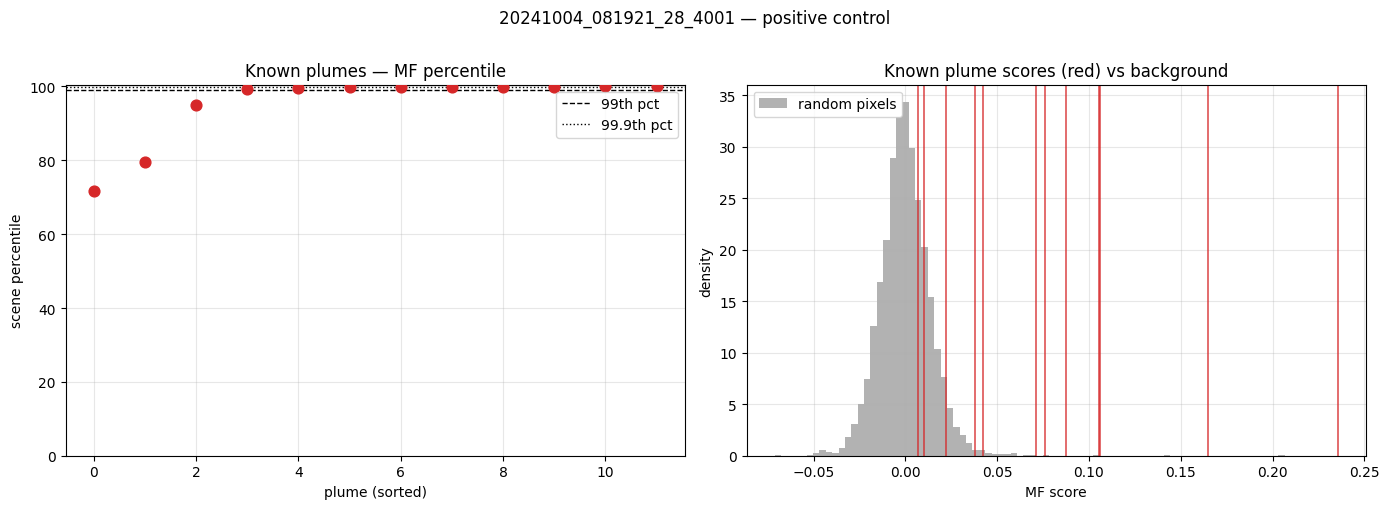

In [ ]:
# Known-plume percentiles against the uniform null.
# Percentile is uniform by construction for a random pixel, so the diagonal
# is the no-skill reference.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

p = np.sort(inframe["percentile"].values)
ax[0].scatter(range(len(p)), p, s=60, c="tab:red", zorder=3)
for lvl, ls in [(99, "--"), (99.9, ":")]:
    ax[0].axhline(lvl, color="k", ls=ls, lw=1, label=f"{lvl}th pct")
ax[0].set_xlabel("plume (sorted)"); ax[0].set_ylabel("scene percentile")
ax[0].set_title("Known plumes — MF percentile")
ax[0].set_ylim(0, 100.5); ax[0].legend(); ax[0].grid(alpha=0.3)

n_null = 5000
fi = np.isfinite(mf)
null_scores = rng.choice(mf[fi], size=min(n_null, fi.sum()), replace=False)
ax[1].hist(null_scores, bins=80, color="tab:gray", alpha=0.6,
           density=True, label="random pixels")
for _, r_ in inframe.iterrows():
    ax[1].axvline(r_["mf_score"], color="tab:red", lw=1.2, alpha=0.8)
ax[1].set_xlabel("MF score"); ax[1].set_ylabel("density")
ax[1].set_title("Known plume scores (red) vs background")
ax[1].legend(); ax[1].grid(alpha=0.3)

fig.suptitle(f"{SCENE_ID} — positive control", y=1.01)
fig.tight_layout()
fig.savefig(FIGDIR / f"positive_control_ranks_{SCENE_ID}.png",
            dpi=150, bbox_inches="tight")
plt.show()

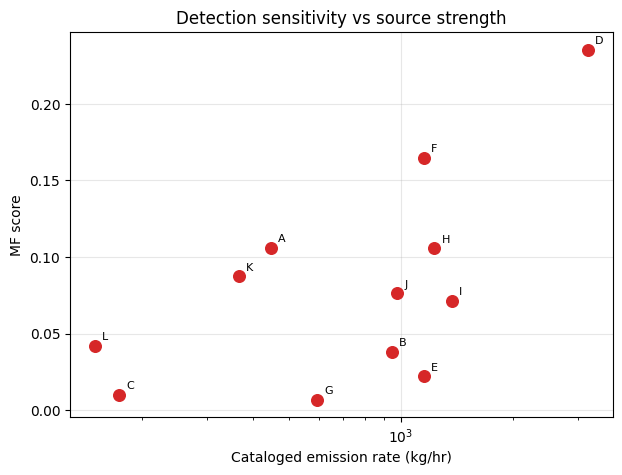

                          label    emission  mf_score  percentile
20241004_081910_00_4001_strip_A  446.018450    0.1062      99.977
20241004_081910_00_4001_strip_B  947.060049    0.0381      99.433
20241004_081910_00_4001_strip_C  173.829073    0.0102      79.501
20241004_081910_00_4001_strip_D 3188.932691    0.2354     100.000
20241004_081910_00_4001_strip_E 1150.274082    0.0221      94.959
20241004_081910_00_4001_strip_F 1151.947043    0.1648      99.995
20241004_081910_00_4001_strip_G  594.918561    0.0069      71.673
20241004_081910_00_4001_strip_H 1231.059431    0.1056      99.976
20241004_081910_00_4001_strip_I 1373.727440    0.0714      99.933
20241004_081910_00_4001_strip_J  977.164188    0.0762      99.945
20241004_081910_00_4001_strip_K  366.006702    0.0873      99.961
20241004_081910_00_4001_strip_L  149.551857    0.0421      99.630


In [ ]:
merged = rank_df.merge(truth_df[["label", "emission"]], on="label", how="left")
sub = merged.dropna(subset=["emission"])
if len(sub):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sub["emission"], sub["mf_score"], s=70, c="tab:red", zorder=3)
    for _, r_ in sub.iterrows():
        ax.annotate(r_["label"][-1], (r_["emission"], r_["mf_score"]),
                    xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Cataloged emission rate (kg/hr)")
    ax.set_ylabel("MF score")
    ax.set_title("Detection sensitivity vs source strength")
    ax.grid(alpha=0.3)
    plt.show()
    print(sub[["label", "emission", "mf_score", "percentile"]].to_string(index=False))

## 6. Does the validation chain ACCEPT a known plume?

Ranking high is necessary but not sufficient — terrain also ranks high. The chain
has to accept spectra at known plume locations while still rejecting the
mineralogy in notebooks 03-06.

Plume pixels are taken from the `ql_ch4_json` polygon where available, otherwise
a small disc around the centroid.

In [ ]:
def plume_pixel_mask(t, lat, lon, radius_px=2):
    """Boolean mask for one ground-truth plume: polygon fill, else a disc."""
    geom = t["geometry"]
    if geom["type"] in ("Polygon", "MultiPolygon"):
        rings = ([geom["coordinates"][0]] if geom["type"] == "Polygon"
                 else [p[0] for p in geom["coordinates"]])
        pts = np.column_stack([lon.ravel(), lat.ravel()])
        m = np.zeros(pts.shape[0], dtype=bool)
        for ring in rings:
            m |= MplPath(np.asarray(ring, dtype=float)).contains_points(pts)
        m = m.reshape(lat.shape)
        if m.sum() >= 4:
            return m

    d = np.sqrt((lat - t["lat"])**2 + (lon - t["lon"])**2)
    r_i, c_i = np.unravel_index(np.nanargmin(d), d.shape)
    m = np.zeros(lat.shape, dtype=bool)
    r0, r1 = max(0, r_i - radius_px), min(lat.shape[0], r_i + radius_px + 1)
    c0, c1 = max(0, c_i - radius_px), min(lat.shape[1], c_i + radius_px + 1)
    m[r0:r1, c0:c1] = True
    return m


results = []
for t in truth:
    m = plume_pixel_mask(t, lat, lon)
    npx = int((m.ravel() & valid).sum())
    if npx < 4:
        results.append({"label": t["label"], "n_px": npx, "verdict": "too few pixels"})
        continue

    ratio, out_m, in_m = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
    if ratio is None:
        results.append({"label": t["label"], "n_px": npx, "verdict": "no match pool"})
        continue

    r_corr, obs_pk, ref_pk = hitran_shape_test(ratio, k, wl_swir)
    vr = ValidationResult(
        scene=t["label"], n_plume_pixels=npx, threshold=np.nan,
        ratio_outside=out_m, ratio_inside=in_m, differential=out_m - in_m,
        hitran_r=r_corr, observed_peak_nm=obs_pk, hitran_peak_nm=ref_pk,
        peak_offset_nm=abs(obs_pk - ref_pk),
    )
    vr.verdict = _verdict(vr)
    results.append({
        "label": t["label"], "n_px": npx,
        "outside": round(out_m, 3), "inside": round(in_m, 3),
        "differential": round(out_m - in_m, 4),
        "r": round(r_corr, 3),
        "obs_peak": round(obs_pk, 1),
        "offset_nm": round(abs(obs_pk - ref_pk), 1),
        "verdict": vr.verdict.split(" - ")[0],
    })
    vr.arrays = {"ratio": ratio, "k_ref": k, "wl_swir": wl_swir}
    t["_vr"] = vr

chain_df = pd.DataFrame(results)
print(chain_df.to_string(index=False))

if "verdict" in chain_df:
    n_acc = (chain_df["verdict"] == "ACCEPT").sum()
    print(f"\nACCEPT: {n_acc} / {len(chain_df)}")

                          label  n_px  outside  inside  differential      r  obs_peak  offset_nm  verdict
20241004_081910_00_4001_strip_A    25    0.993   0.976        0.0169  0.636    2370.3        0.0 MARGINAL
20241004_081910_00_4001_strip_B    25    0.972   0.969        0.0025  0.159    2429.8       59.5   REJECT
20241004_081910_00_4001_strip_C    25    0.988   0.983        0.0055  0.186    2429.8       59.5   REJECT
20241004_081910_00_4001_strip_D    25    1.003   0.975        0.0277  0.800    2345.5       24.8   REJECT
20241004_081910_00_4001_strip_E    25    0.996   0.985        0.0106  0.605    2345.5       24.8   REJECT
20241004_081910_00_4001_strip_F    25    0.991   0.965        0.0259  0.722    2345.5       24.8   REJECT
20241004_081910_00_4001_strip_G    25    0.982   0.971        0.0106  0.241    2414.9       44.6   REJECT
20241004_081910_00_4001_strip_H    25    0.986   0.990       -0.0041 -0.032    2434.7       64.5   REJECT
20241004_081910_00_4001_strip_I    25    0.973

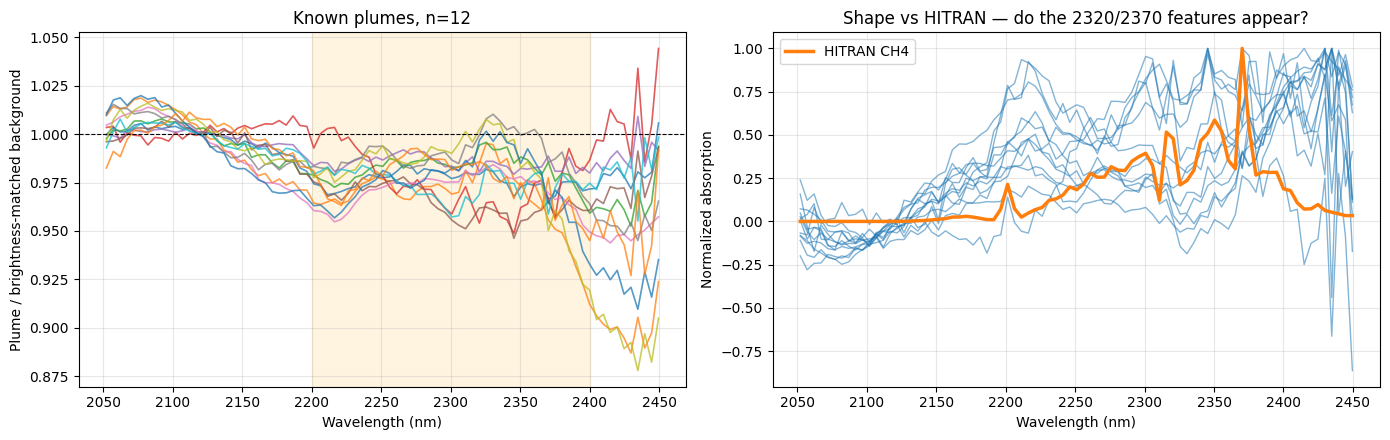

In [ ]:
# Spectra of every known plume, overlaid on HITRAN
have = [t for t in truth if "_vr" in t]
if have:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for t in have:
        ax[0].plot(wl_swir, t["_vr"].arrays["ratio"], lw=1.2, alpha=0.75)
    ax[0].axhline(1.0, color="k", ls="--", lw=0.8)
    ax[0].axvspan(BAND_LO, BAND_HI, alpha=0.12, color="orange")
    ax[0].set_xlabel("Wavelength (nm)")
    ax[0].set_ylabel("Plume / brightness-matched background")
    ax[0].set_title(f"Known plumes, n={len(have)}")
    ax[0].grid(alpha=0.3)

    for t in have:
        d = 1.0 - t["_vr"].arrays["ratio"]
        mx = np.nanmax(d)
        if mx > 0:
            ax[1].plot(wl_swir, d / mx, lw=1.0, alpha=0.55, color="tab:blue")
    ax[1].plot(wl_swir, k, lw=2.5, color="tab:orange", label="HITRAN CH4")
    ax[1].set_xlabel("Wavelength (nm)")
    ax[1].set_ylabel("Normalized absorption")
    ax[1].set_title("Shape vs HITRAN — do the 2320/2370 features appear?")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIGDIR / f"positive_control_spectra_{SCENE_ID}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
from collections import Counter
print(Counter(f["geometry"]["type"] for f in feats))
print(json.dumps(feats[0]["geometry"], indent=1)[:400])

Counter({'Point': 12})
{
 "coordinates": [
  40.41565101864123,
  35.36718673085282
 ],
 "type": "Point"
}


In [ ]:
_mask = plume_pixel_mask  


def mask_radius(t, lat, lon, rad_px):
    """Square window of half-width rad_px centered on the reported point."""
    d = np.sqrt((lat - t["lat"])**2 + (lon - t["lon"])**2)
    r_i, c_i = np.unravel_index(np.nanargmin(d), d.shape)
    m = np.zeros(lat.shape, dtype=bool)
    m[max(0, r_i-rad_px):r_i+rad_px+1,
      max(0, c_i-rad_px):c_i+rad_px+1] = True
    return m


def shape_test_windowed(ratio, k_ref, wl, lo=2150, hi=2400, max_lag=8):
    """Correlation over the high-SNR window, with cross-correlation lag."""
    w = (wl >= lo) & (wl <= hi)
    d, kk, wl_w = 1.0 - ratio[w], k_ref[w], wl[w]
    dz = (d - d.mean()) / (d.std() + 1e-12)
    kz = (kk - kk.mean()) / (kk.std() + 1e-12)
    r = float(np.dot(dz, kz) / len(dz))
    best_r, best_lag = -2.0, 0
    for lag in range(-max_lag, max_lag + 1):
        rr = float(np.dot(dz, np.roll(kz, lag)) / len(dz))
        if rr > best_r:
            best_r, best_lag = rr, lag
    return r, best_r, best_lag * float(np.median(np.diff(wl_w)))


out = []
for rad_px in (0, 1, 2):
    for t in truth:
        m = mask_radius(t, lat, lon, rad_px)
        if (m.ravel() & valid).sum() < 1:
            continue
        res = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
        if res[0] is None:
            continue
        ratio_t, o_t, i_t = res
        r_full, _, _ = hitran_shape_test(ratio_t, k, wl_swir)
        r_win, r_lag, lag_nm = shape_test_windowed(ratio_t, k, wl_swir)
        out.append({"rad": rad_px, "px": int(m.sum()), "id": t["label"][-1],
                    "diff": round(o_t - i_t, 4),
                    "r_full": round(r_full, 3),
                    "r_win": round(r_win, 3),
                    "r_aligned": round(r_lag, 3),
                    "lag_nm": round(lag_nm, 1)})

res_df = pd.DataFrame(out)
print(res_df.groupby("rad")[["diff", "r_full", "r_win", "r_aligned"]]
      .median().round(3).to_string())
print("\nper-plume at the tightest radius:")
print(res_df[res_df["rad"] == 0].to_string(index=False))

      diff  r_full  r_win  r_aligned
rad                                 
0    0.019   0.403  0.536      0.598
1    0.014   0.340  0.373      0.515
2    0.010   0.264  0.232      0.400

per-plume at the tightest radius:
 rad  px id    diff  r_full  r_win  r_aligned  lag_nm
   0   1  A  0.0547   0.714  0.667      0.667     0.0
   0   1  B -0.0123   0.063  0.237      0.545    19.9
   0   1  C  0.0013  -0.123 -0.559     -0.251   -39.8
   0   1  D  0.0625   0.886  0.867      0.867     0.0
   0   1  E  0.0170   0.407  0.157      0.581   -24.8
   0   1  F  0.0805   0.753  0.781      0.781     0.0
   0   1  G  0.0020   0.018 -0.438     -0.197    39.8
   0   1  H  0.0174   0.399  0.652      0.652     0.0
   0   1  I  0.0174   0.369  0.591      0.616    19.9
   0   1  J  0.0253   0.707  0.619      0.619     0.0
   0   1  K  0.0273   0.444  0.481      0.481     0.0
   0   1  L  0.0203   0.364  0.358      0.446    14.9


In [ ]:
fi = np.isfinite(mf)
rows_i, cols_i = np.where(fi)
null = []
for _ in range(300):
    j = rng.integers(len(rows_i))
    m = np.zeros(lat.shape, dtype=bool)
    m[rows_i[j], cols_i[j]] = True
    res = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
    if res[0] is None:
        continue
    _, r_lag, lag_nm = shape_test_windowed(res[0], k, wl_swir)
    null.append({"r_aligned": r_lag, "lag_nm": lag_nm})

null_df = pd.DataFrame(null)
strong = res_df[(res_df["rad"] == 0) & (res_df["id"].isin(list("ADFJHI")))]

print(f"null r_aligned : median {null_df['r_aligned'].median():.3f}  "
      f"95th {null_df['r_aligned'].quantile(0.95):.3f}  "
      f"99th {null_df['r_aligned'].quantile(0.99):.3f}")
print(f"strong plumes  : median {strong['r_aligned'].median():.3f}  "
      f"min {strong['r_aligned'].min():.3f}")
print(f"|lag| <= 20nm in null: "
      f"{(null_df['lag_nm'].abs() <= 20).mean()*100:.1f}%")

null r_aligned : median 0.355  95th 0.748  99th 0.789
strong plumes  : median 0.659  min 0.616
|lag| <= 20nm in null: 37.0%


## 7. Threshold calibration on held-out plumes

The `_verdict()` thresholds were set by judgment, not derived. With known
positives available they can be fitted — but fitting and evaluating on the same
plumes would be circular, so plumes are split in half.

With a handful of plumes this is a weak estimate. It is reported with its
sample size rather than presented as a calibration.

In [ ]:
usable = chain_df[chain_df["verdict"].isin(["ACCEPT", "REJECT", "MARGINAL"])] \
    if "verdict" in chain_df else pd.DataFrame()

if len(usable) < 4:
    print(f"Only {len(usable)} usable plume(s) - too few to split. "
          "Report descriptive statistics instead of fitting thresholds.")
    if len(usable):
        print(usable[["r", "offset_nm", "differential", "outside"]].describe()
              .to_string())
else:
    idx = rng.permutation(len(usable))
    half = len(idx) // 2
    fit  = usable.iloc[idx[:half]]
    test = usable.iloc[idx[half:]]
    print(f"fit on {len(fit)}, evaluate on {len(test)}\n")

    # Loosest thresholds that still admit every plume in the fit set
    r_thr   = float(fit["r"].min())
    off_thr = float(fit["offset_nm"].max())
    dif_thr = float(fit["differential"].min())
    print(f"fitted   r >= {r_thr:.3f} | offset <= {off_thr:.1f} nm | "
          f"differential >= {dif_thr:.4f}")
    print(f"current  r >= 0.800 | offset <= 15.0 nm | differential >= 0.0050\n")

    passed = ((test["r"] >= r_thr) & (test["offset_nm"] <= off_thr) &
              (test["differential"] >= dif_thr))
    print(f"held-out plumes passing fitted thresholds: {passed.sum()} / {len(test)}")

    # False-positive cost: same thresholds against random background patches
    fi = np.isfinite(mf)
    rows_, cols_ = np.where(fi)
    n_fp, fp_hits = 200, 0
    for _ in range(n_fp):
        j = rng.integers(len(rows_))
        r_i, c_i = rows_[j], cols_[j]
        m = np.zeros(lat.shape, dtype=bool)
        m[max(0, r_i-2):r_i+3, max(0, c_i-2):c_i+3] = True
        if (m.ravel() & valid).sum() < 4:
            continue
        ratio_n, o_n, i_n = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
        if ratio_n is None:
            continue
        r_n, opk_n, rpk_n = hitran_shape_test(ratio_n, k, wl_swir)
        if (r_n >= r_thr and abs(opk_n - rpk_n) <= off_thr
                and (o_n - i_n) >= dif_thr):
            fp_hits += 1
    print(f"random background patches passing: {fp_hits} / {n_fp} "
          f"({100*fp_hits/n_fp:.1f}%)")

fit on 6, evaluate on 6

fitted   r >= -0.032 | offset <= 64.5 nm | differential >= -0.0041
current  r >= 0.800 | offset <= 15.0 nm | differential >= 0.0050

held-out plumes passing fitted thresholds: 5 / 6
random background patches passing: 68 / 200 (34.0%)


## 8. Conclusion

Fill in from the outputs above.

| Question | Evidence |
|---|---|
| Do known plumes rank near the top? | Section 5 percentile table |
| Does the chain accept them? | Section 6 ACCEPT count |
| Do the fitted thresholds generalize? | Section 7 held-out pass rate |
| What false-positive rate comes with them? | Section 7 background patch rate |

**If known plumes rank high and are accepted:** the chain is validated on this
scene. The Permian REJECT becomes a calibrated negative result, and the submission
is a validated pipeline plus a documented false-positive case.

**If known plumes rank high but are rejected:** detection works, the shape test is
too strict. Recompute correlation over ~2150-2450 nm to remove continuum
inflation, and replace the single-argmax peak metric with cross-correlation lag.

**If known plumes do not rank high:** the filter is not sensitive to plumes at this
scale. Check plume size against the 43.6 m GSD, haze, and off-nadir geometry
before concluding anything about any other scene.

Any of the three is a reportable result. The third is the most interesting and the
least convenient.

In [ ]:
from scipy.ndimage import binary_dilation

def grow(seed_rc, mf, thresh, max_px=40):
    """Grow a region from a seed through contiguous above-threshold pixels."""
    m = np.zeros(mf.shape, bool); m[seed_rc] = True
    for _ in range(6):
        cand = binary_dilation(m) & (mf > thresh) & np.isfinite(mf)
        if cand.sum() > max_px or cand.sum() == m.sum():
            break
        m = cand
    return m


fi = np.isfinite(mf)
THRESH = np.nanpercentile(mf, 99)

sig = []
for t in truth:
    d = np.sqrt((lat - t["lat"])**2 + (lon - t["lon"])**2)
    seed = np.unravel_index(np.nanargmin(d), d.shape)
    m = grow(seed, mf, THRESH)
    if (m.ravel() & valid).sum() < 3:
        continue
    res = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
    if res[0] is None:
        continue
    _, r_lag, lag_nm = shape_test_windowed(res[0], k, wl_swir)
    sig.append({"id": t["label"][-1], "px": int(m.sum()),
                "r_aligned": round(r_lag, 3), "lag_nm": round(lag_nm, 1)})

sig_df = pd.DataFrame(sig)
print(sig_df.to_string(index=False))

id  px  r_aligned  lag_nm
 A  13      0.648     0.0
 B  18      0.510    19.9
 D  26      0.848     0.0
 E   9      0.759     0.0
 F  18      0.739     0.0
 H  12      0.410    19.9
 I  19      0.621    19.9
 J  30      0.755     0.0
 K   5      0.447     0.0
 L   9      0.551     5.0


In [ ]:
from scipy.ndimage import binary_dilation

def grow(seed_rc, mf, thresh, max_px=40):
    """Grow a region from a seed pixel through contiguous above-threshold pixels."""
    m = np.zeros(mf.shape, bool); m[seed_rc] = True
    for _ in range(6):
        cand = binary_dilation(m) & (mf > thresh) & np.isfinite(mf)
        if cand.sum() > max_px or cand.sum() == m.sum():
            break
        m = cand
    return m


fi = np.isfinite(mf)
THRESH = np.nanpercentile(mf, 99)

# Seed the null only from above-threshold pixels, matching how plume seeds behave,
# and exclude anything near a known plume.
hi_r, hi_c = np.where((mf > THRESH) & fi)

plume_rc = []
for t in truth:
    d = np.sqrt((lat - t["lat"])**2 + (lon - t["lon"])**2)
    plume_rc.append(np.unravel_index(np.nanargmin(d), d.shape))

def far_from_plumes(r, c, min_px=15):
    return all(np.hypot(r - pr, c - pc) > min_px for pr, pc in plume_rc)

null3, null_px = [], []
tries = 0
while len(null3) < 200 and tries < 5000:
    tries += 1
    j = rng.integers(len(hi_r))
    r0, c0 = hi_r[j], hi_c[j]
    if not far_from_plumes(r0, c0):
        continue
    m = grow((r0, c0), mf, THRESH)
    if (m.ravel() & valid).sum() < 3:
        continue
    res = brightness_matched_ratio(X, valid, m.ravel(), wl_swir)
    if res[0] is None:
        continue
    _, r_lag, _ = shape_test_windowed(res[0], k, wl_swir)
    null3.append(r_lag); null_px.append(int(m.sum()))

null3 = np.array(null3)
print(f"null n={len(null3)} from {tries} draws | region size "
      f"median {np.median(null_px):.0f} px (plumes median {sig_df['px'].median():.0f})")
print(f"null    median {np.median(null3):.3f}  95th {np.quantile(null3,0.95):.3f}  "
      f"99th {np.quantile(null3,0.99):.3f}")
print(f"plumes  median {sig_df['r_aligned'].median():.3f}  max {sig_df['r_aligned'].max():.3f}")
print(f"above null 95th: {(sig_df['r_aligned'] > np.quantile(null3,0.95)).sum()} / {len(sig_df)}")

null n=200 from 332 draws | region size median 12 px (plumes median 16)
null    median 0.723  95th 0.796  99th 0.851
plumes  median 0.635  max 0.848
above null 95th: 1 / 10


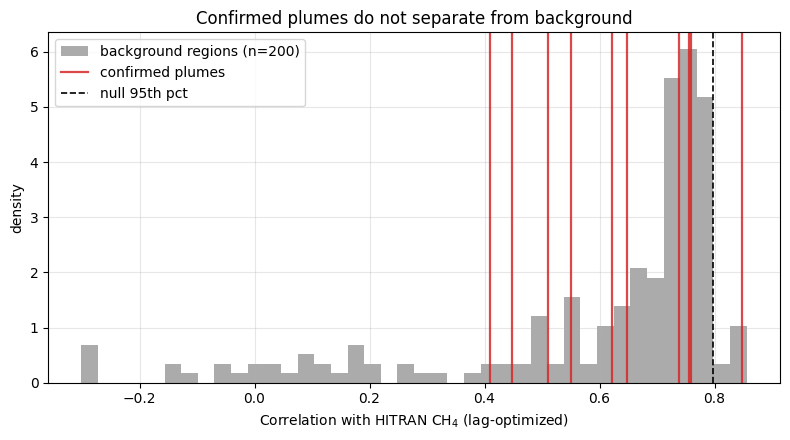

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null3, bins=40, color="tab:gray", alpha=0.65,
        density=True, label=f"background regions (n={len(null3)})")
for i, v in enumerate(sig_df["r_aligned"]):
    ax.axvline(v, color="tab:red", lw=1.6, alpha=0.85,
               label="confirmed plumes" if i == 0 else None)
ax.axvline(np.quantile(null3, 0.95), color="k", ls="--", lw=1.2,
           label="null 95th pct")
ax.set_xlabel("Correlation with HITRAN CH$_4$ (lag-optimized)")
ax.set_ylabel("density")
ax.set_title("Confirmed plumes do not separate from background")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/null_vs_plumes.png", dpi=150, bbox_inches="tight")
plt.show()